In [2]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import seaborn as sns
import torch

import sys
sys.path.append("../")

def retime(df):
    """
    Recalculate segment time, treating the entire dataframe as one segment.

    Args:
        df (pd.DataFrame): Measurement data. Includes a column
                           'Segment Time, S'

    Returns:
        pd.DataFrame: Dataframe where 'Segment Time, S' is reindexed
                      to start from 0.
    """
    df_ = df.copy().reset_index(drop=True)
    df_["Segment Time, S"] = df_["Total Time, S"] - df_.loc[0, "Total Time, S"]
    return df_
segments_of_interest = [
    "Charge depleting cycle",
    "Charge sustaining cycle",
    'Rate test C/2 cycle charge CC',
    'PsRP 1 C/2 diagnostic cycle charge',
    'PsRP 2 C/2 diagnostic cycle charge',
    'Rate test 1C cycle charge CC',
    'PsRP 1 1C diagnostic cycle charge',
    'PsRP 2 1C diagnostic cycle charge',
]

hdf = pd.HDFStore('../../data/data_raw.h5', mode='r')


# 1 Model input

What follows is a summary of what goes into the model:

- "Charge depleting cycle",
    - has 10 minute repeats of power control
    - split into 10 minute windows (every 599 or 600 rows exactly)
    - for each window, extract final 2 minutes [:-120] for held out test set input
    - extract 5 random 120s windows from the first 8 minutes for training set input
- "Charge sustaining cycle",
    - last 30 minutes pull out for held out test set input
    - first 1.5 hours, pull out 5 random 30 minute segments
- 'Rate test C/2 cycle charge CC',
    - grab 10x random 15 minute windows
- 'PsRP 1 C/2 diagnostic cycle charge',
    - grab 10x random 15 minute windows
- 'PsRP 2 C/2 diagnostic cycle charge',
    - grab 10x random 15 minute windows
- 'Rate test 1C cycle charge CC',
    - grab 10x random 8 minute windows
- 'PsRP 1 1C diagnostic cycle charge',
    - grab 10x random 8 minute windows
- 'PsRP 2 1C diagnostic cycle charge',
    - grab 10x random 8 minute windows

The sampling from the latter 6 segments is not as simple as it appears. We first take 10x as many random samples as we need, save them all as an h5 file, and then sample them for the training data when the training/testing script is run. 

due to the varying signal length, particularly in the type D cells. As a result, instead of just taking 10 segments per sample, we sample enough to cover the whole range, and then multiply by 10. For example,

120 min sample / 15 minute windows = 8 segments (rounded up if necessary) x 10 = 80 total samples saved to an h5 file.

Text(0.5, 1.0, 'Type D Cells - Rate Test 1C Cycle Charge CC Segments')

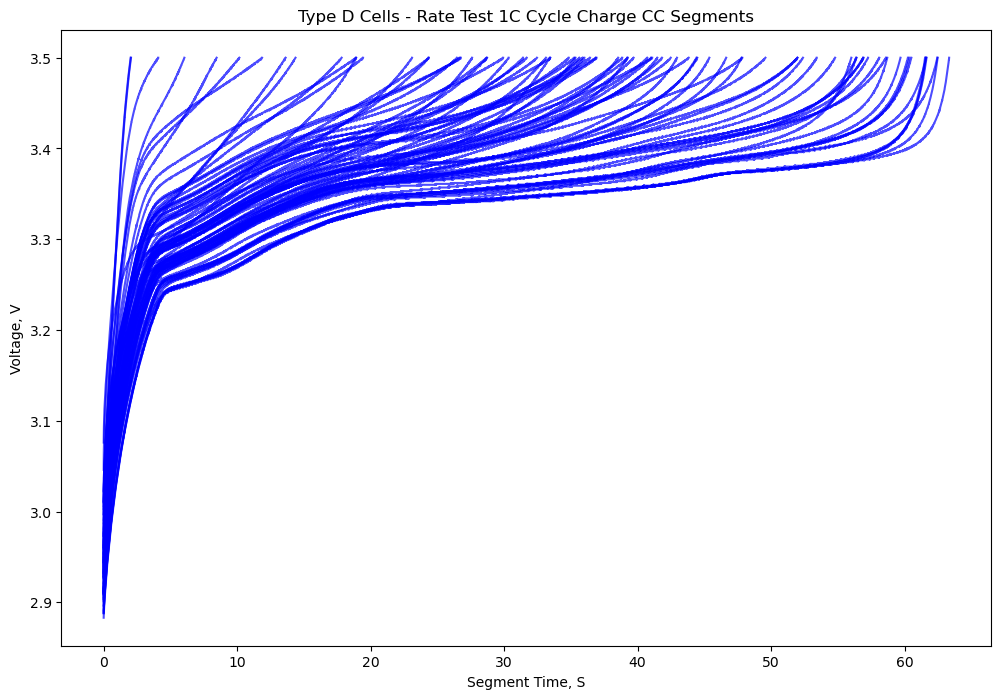

In [2]:

keys_d = [key for key in hdf.keys() if '/D/' in key]

fig, ax = plt.subplots(figsize=(12,8))

for df in [hdf.get(key) for key in keys_d]:
    df_segment = df.loc[["Rate test 1C cycle charge CC" in seg_desc and 'rest' not in seg_desc and 'CV' not in seg_desc for seg_desc in df['Segment Description']]]
    df_segment = retime(df_segment)
    ax.plot(df_segment['Segment Time, S'] / 60, df_segment['Voltage, V'], alpha=0.7, color='blue')
    
    
ax.set_xlabel('Segment Time, S')
ax.set_ylabel('Voltage, V')
ax.set_title('Type D Cells - Rate Test 1C Cycle Charge CC Segments')

Text(0.5, 1.0, 'Cell /D/data_240624_ReCellML_A123_Cell01_charac_30C - Full Voltage Curve')

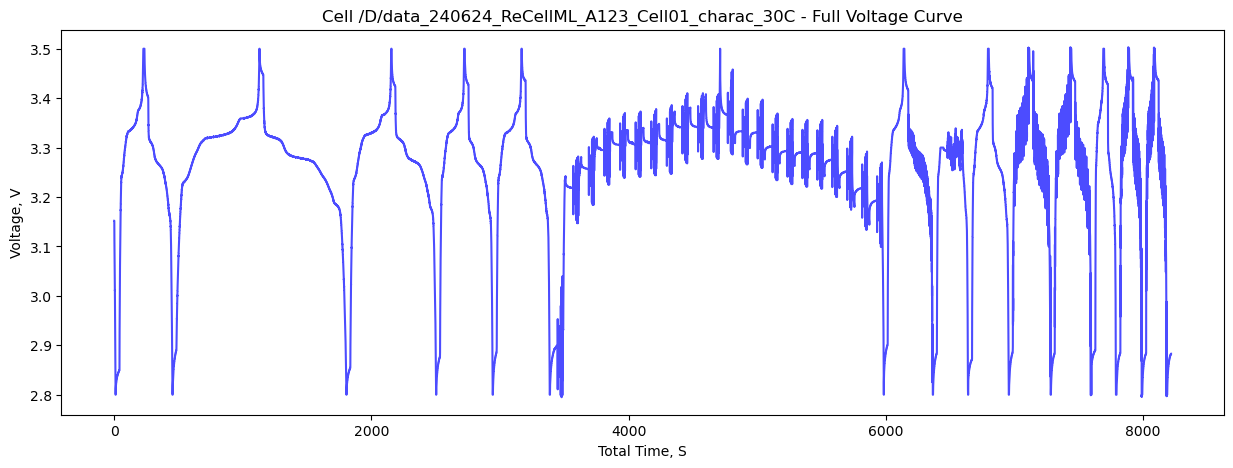

In [25]:
key = hdf.keys()[0]
df = hdf.get(key)

fig, ax = plt.subplots(figsize=(15,5))

ax.plot(df['Total Time, S'] / 60, df['Voltage, V'], alpha=0.7, color='blue')

ax.set_xlabel('Total Time, S')
ax.set_ylabel('Voltage, V')
ax.set_title(f'Cell {key} - Full Voltage Curve')    


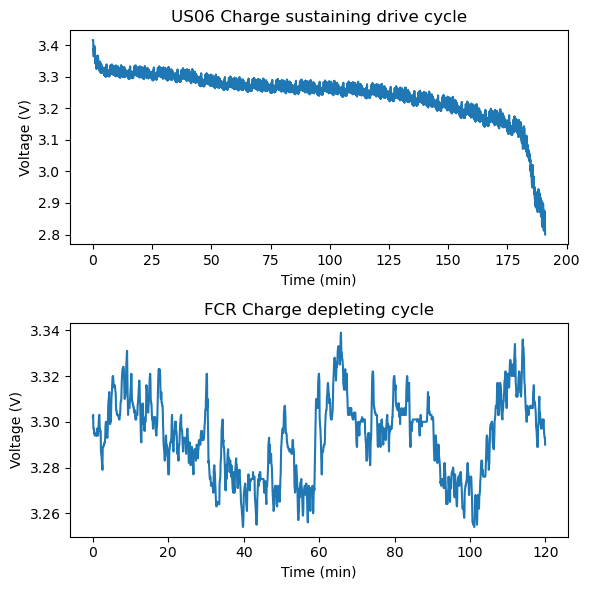

In [33]:
charge_cycles = [
    "Charge depleting cycle",
    "Charge sustaining cycle",
]
fig, ax = plt.subplots(2,1,figsize=(6,6))

for i, cycle in enumerate(charge_cycles):
    df_seg = df.loc[[cycle in seg_desc and 'rest' not in seg_desc for seg_desc in df['Segment Description']]]
    ax[i].plot(df_seg['Segment Time, S']/60, df_seg['Voltage, V'])
    ax[i].set_xlabel("Time (min)")
    ax[i].set_ylabel("Voltage (V)")

ax[0].set_title("US06 Charge sustaining drive cycle")
ax[1].set_title("FCR Charge depleting cycle")
fig.tight_layout()

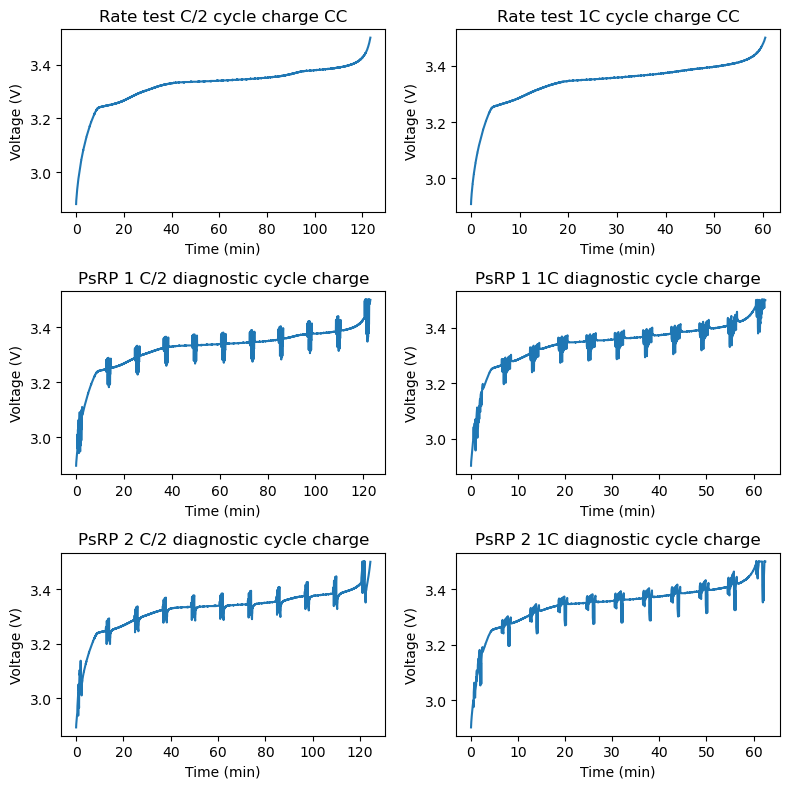

In [38]:
other_segments = [
    'Rate test C/2 cycle charge CC',
    'Rate test 1C cycle charge CC',
    'PsRP 1 C/2 diagnostic cycle charge',
    'PsRP 1 1C diagnostic cycle charge',
    'PsRP 2 C/2 diagnostic cycle charge',
    'PsRP 2 1C diagnostic cycle charge',
]
fig, ax = plt.subplots(3,2,figsize=(8,8))
ax = ax.flatten()
for i, segment in enumerate(other_segments):
    df_seg = df.loc[[segment in seg_desc and 'rest' not in seg_desc and 'CV' not in seg_desc for seg_desc in df['Segment Description']]]
    df_seg = retime(df_seg)
    ax[i].plot(df_seg['Segment Time, S']/60, df_seg['Voltage, V'])
    ax[i].set_xlabel("Time (min)")
    ax[i].set_ylabel("Voltage (V)")
    ax[i].set_title(segment)

fig.tight_layout()

I would like to take 8 minute segments from the graph above, but I can't if some of the segments are less, than 8 minutes long. Those segments are excluded from the data.

I also shouldn't include 10 eight minute segments of the data if the total length is only 9 or 10 minutes long, because then the testing data will include duplicate data from the training data, and cause data leakage. 


From these segments, we take the voltage, current, and power data, as well as the temperature, and initial, final, and mean soc.

Text(0.5, 0, 'Time Step')

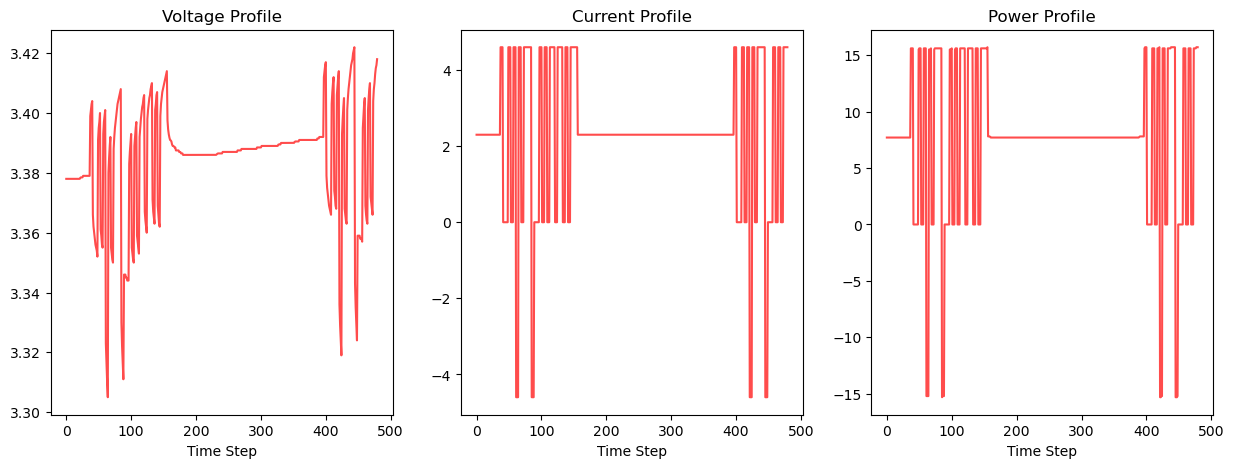

In [3]:
hdf = pd.HDFStore('../../data/data_partial_charge_for_ml.h5', mode='r')

df = hdf.get('/PsRP_1_1C')

fig, ax = plt.subplots(1, 3, figsize=(15,5))

ax[0].plot(range(480), df.iloc[0].filter(regex='^voltage'), alpha=0.7, color='red', label='PsRP 1 1C Diagnostic Cycle Charge')
ax[0].set_title('Voltage Profile')
ax[0].set_xlabel('Time Step')

ax[1].plot(range(480), df.iloc[0].filter(regex='^current'), alpha=0.7, color='red')
ax[1].set_title('Current Profile')
ax[1].set_xlabel('Time Step')

ax[2].plot(range(480), df.iloc[0].filter(regex='^power'), alpha=0.7, color='red')
ax[2].set_title('Power Profile')
ax[2].set_xlabel('Time Step')

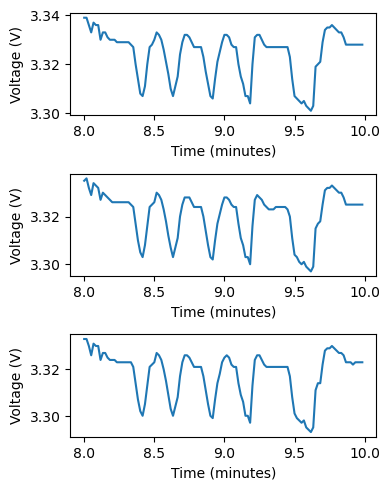

In [4]:
df = hdf.get('/Charge_Depleting')

df = df[df['split_type'] == 'testing']

fig, ax = plt.subplots(3, 1, figsize=(4,5))

for i in range(3):
    ax[i].plot(np.linspace(8,10,121), df.iloc[i].filter(regex='^voltage'))
    ax[i].set_xlabel('Time (minutes)')
    ax[i].set_ylabel('Voltage (V)')
fig.tight_layout()

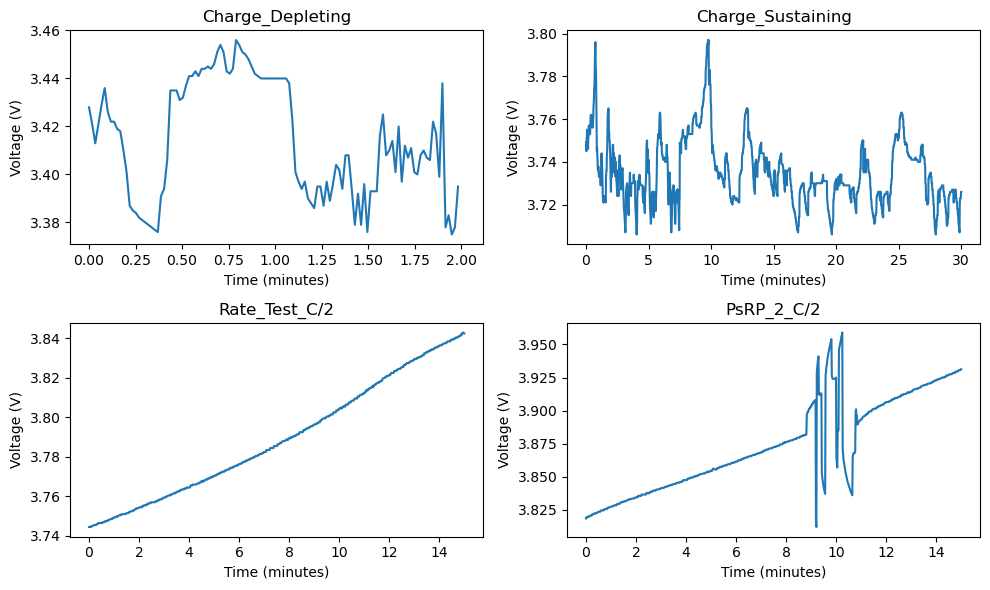

In [15]:
segments = [
    "Charge_Depleting",
    "Charge_Sustaining",
    "Rate_Test_C/2",
    "PsRP_2_C/2",
]
lengths = [
    121,
    1800,
    900,
    900,
]

fig, ax = plt.subplots(2,2, figsize=(10,6))
ax = ax.flatten()
for i, segment in enumerate(segments):
    df = hdf.get(segment)
    ax[i].plot(np.linspace(0, lengths[i]/60, lengths[i]), df.iloc[-1].filter(regex='^voltage'))
    ax[i].set_title(segment)
    ax[i].set_xlabel('Time (minutes)')
    ax[i].set_ylabel('Voltage (V)')

fig.tight_layout()

In [11]:
df = hdf.get('/Charge_Sustaining')

df

,soc_mean,soc_initial,soc_final,split_type,voltage_ 0.0s,voltage_ 4.0s,voltage_ 8.0s,voltage_ 12.0s,voltage_ 16.0s,voltage_ 20.0s,...,Charge depleting cycle charge throughput,Charge sustaining cycle charge efficiency,Post C/10 charge relaxation fit MSE,Post C/5 charge relaxation fit MSE,Post C/3 charge relaxation fit MSE,Post P/3 charge relaxation fit MSE,Post C/2 charge relaxation fit MSE,Post 1C charge relaxation fit MSE,Thickness growth,Volume growth
0,-0.311530,-0.325939,-0.331158,testing,3.302,3.302,3.302,3.302,3.300,3.295,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
1,-0.288423,-0.307635,-0.279822,training,3.292,3.292,3.292,3.293,3.293,3.295,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
2,-0.288423,-0.307635,-0.279822,training,3.292,3.292,3.292,3.293,3.293,3.295,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
3,-0.304755,-0.312454,-0.283460,training,3.299,3.304,3.308,3.303,3.302,3.302,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
4,-0.317171,-0.282614,-0.325994,training,3.310,3.309,3.309,3.307,3.306,3.310,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12949,0.610824,0.591744,0.601171,training,3.766,3.770,3.771,3.774,3.778,3.780,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN
12950,0.591211,0.609074,0.578634,training,3.761,3.762,3.762,3.763,3.762,3.757,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN
12951,0.593130,0.609143,0.582079,training,3.738,3.750,3.751,3.751,3.752,3.752,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN
12952,0.602922,0.585316,0.621476,training,3.738,3.738,3.741,3.741,3.735,3.735,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN


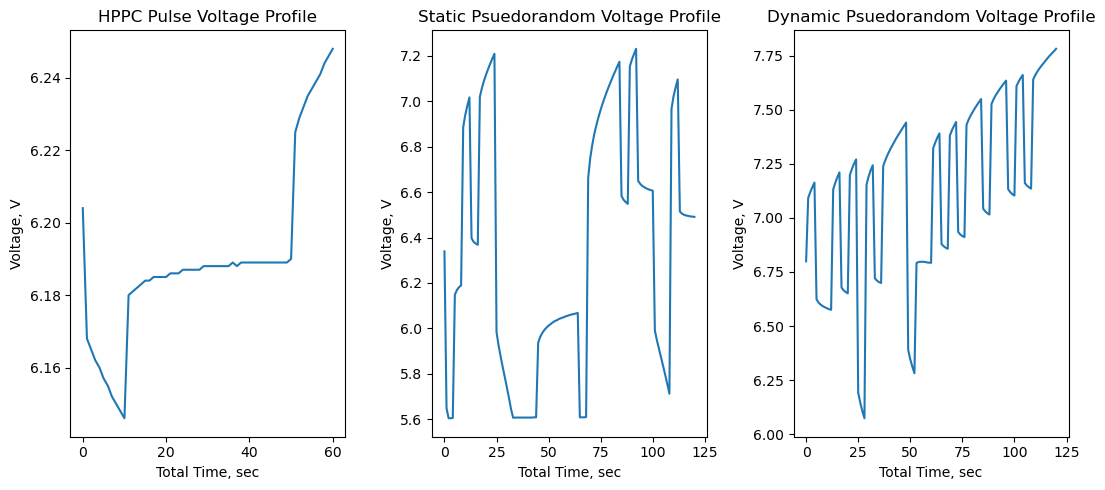

In [23]:
hdf = pd.HDFStore('../../data/data_for_ml.h5', 'r')

keys = hdf.keys()
key = [
    keys[3],
    keys[4],
    keys[1],
]

# df = hdf.get(key)

fig, ax = plt.subplots(1,3,figsize=(11,5))

for key, subplot in zip(key, ax):
    df = hdf.get(key)
    subplot.plot(range(len(df.iloc[0].filter(regex='voltage'))), df.iloc[0].filter(regex='voltage'))
    # subplot.set_title(f'Cell {key} Voltage Profile')
    subplot.set_xlabel('Total Time, sec')
    subplot.set_ylabel('Voltage, V')

ax[0].set_title('HPPC Pulse Voltage Profile')
ax[1].set_title('Static Psuedorandom Voltage Profile')
ax[2].set_title('Dynamic Psuedorandom Voltage Profile')

fig.tight_layout()

In [10]:
keys

['/DCIR',
 '/Dynamic_PsRP_1_1C',
 '/Dynamic_PsRP_2_1C',
 '/Static_HPPC',
 '/Static_PsRP_1',
 '/Static_PsRP_2_Chg',
 '/Static_PsRP_2_Dis',
 '/Static_Rapid',
 '/Dynamic_PsRP_2_C/2',
 '/Dynamic_PsRP_1_C/2']

In [7]:
from sklearn.model_selection import GroupShuffleSplit

hdf = pd.HDFStore('../../data/data_partial_charge_for_ml.h5', mode='r')

keys = hdf.keys()
df = hdf.get("Charge_Sustaining_Time_Variable")
_charge_sustaining_time_variable = df[df["cell_id"].str.startswith("A_")]
_charge_sustaining_time_variable = _charge_sustaining_time_variable.reset_index(drop=True)

# _charge_sustaining_time_variable['soc_mean'] = abs(_charge_sustaining_time_variable['soc_mean'])

#time variable pulses are separated by length of sample
charge_sustaining_time_variable_15min = _charge_sustaining_time_variable[_charge_sustaining_time_variable['segment_length'] == 'fifteen_mins']
charge_sustaining_time_variable_30min = _charge_sustaining_time_variable[_charge_sustaining_time_variable['segment_length'] == 'thirty_mins']
charge_sustaining_time_variable_45min = _charge_sustaining_time_variable[_charge_sustaining_time_variable['segment_length'] == 'fortyfive_mins']  
charge_sustaining_time_variable_60min = _charge_sustaining_time_variable[_charge_sustaining_time_variable['segment_length'] == 'sixty_mins']

tests = {
    "Charge_Sustaining_Time_Variable_15mins": charge_sustaining_time_variable_15min,
    "Charge_Sustaining_Time_Variable_30mins": charge_sustaining_time_variable_30min,
    "Charge_Sustaining_Time_Variable_45mins": charge_sustaining_time_variable_45min,
    "Charge_Sustaining_Time_Variable_60mins": charge_sustaining_time_variable_60min,
}
target = "C/3 discharge capacity"

pulse = "Charge_Sustaining_Time_Variable_15mins"

# for test in tests:

#     # Give each row a unique "sample_id"
#     tests[test]["sample_id"] = tests[test].index

df = tests[pulse]
df = df[df[target].notna()]


splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for i, (idx_train, idx_test) in enumerate(
    splitter.split(
        df,
        groups=df["measurement_id"],
    )
):
    train = df.iloc[idx_train]
    test = df.iloc[idx_test]

    print(train.shape, test.shape)
    print(train['measurement_id'].nunique()) 
    print(test['measurement_id'].nunique())




(195, 10825) (50, 10825)
39
10


In [10]:
print(train['measurement_id'].unique()) 
print(test['measurement_id'].unique())

[28 29 30 31 32 33 34 35 36 37 38 39 40 42 43 44 46 48 49 50 51 52 56 57
 58 60 61 62 63 64 65 66 67 68 69 70 71 74 76]
[41 45 47 53 54 55 59 72 73 75]


In [16]:
features_charge_sustaining_time_variable = pd.read_pickle("../../data/features_partial_charge_sustaining_cycle_time_variable.pkl")

features_charge_sustaining_time_variable


,temperature,soc_mean,soc_initial,soc_final,segment_length,voltage_ 0.0s,voltage_ 4.0s,voltage_ 8.0s,voltage_ 12.0s,voltage_ 16.0s,...,power_3587.0s,power_3589.0s,power_3590.0s,power_3591.0s,power_3593.0s,power_3594.0s,power_3595.0s,power_3597.0s,power_3598.0s,power_3599.0s
0,29.875555555555554,-0.30214430264260456,-0.2799537371713021,-0.320779328819632,fifteen_mins,3.269,3.27,3.27,3.271,3.272,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29.837777777777777,-0.2849918318262482,-0.29706667660869057,-0.28596063363958163,fifteen_mins,3.288,3.284,3.284,3.284,3.284,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,29.866666666666667,-0.2849837732295984,-0.2798009017175988,-0.29917395331884256,fifteen_mins,3.272,3.272,3.272,3.27,3.272,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,29.604444444444443,-0.3117279809894314,-0.31587933154635545,-0.3090503655922474,fifteen_mins,3.302,3.302,3.302,3.3,3.302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,29.68888888888889,-0.3033491709072238,-0.2869100660034963,-0.3157820726212715,fifteen_mins,3.299,3.302,3.303,3.303,3.297,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,47.0,0.6012630255975336,0.6040319525491914,0.6272647159938184,sixty_mins,3.79,3.79,3.791,3.792,3.792,...,-57.8,-50.0,-50.0,-50.0,-42.6,-42.6,-42.6,-34.9,-34.9,-34.9
16,46.997083333333336,0.6086713587150262,0.581218107416943,0.6119963339821441,sixty_mins,3.714,3.723,3.724,3.725,3.725,...,37.0,37.0,37.0,36.9,36.9,36.9,53.2,53.2,53.2,69.4
17,46.998194444444444,0.6069079740476355,0.5880549272049025,0.5968355665722729,sixty_mins,3.726,3.727,3.728,3.729,3.729,...,-65.0,-65.0,-65.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18,47.0,0.6022312757567119,0.6162467782784765,0.6224309606587363,sixty_mins,3.79,3.78,3.779,3.771,3.763,...,-51.1,-51.0,-54.4,-54.4,-54.3,-58.4,-58.4,-58.4,-64.2,-64.2


In [17]:
df['temperature']

KeyError: 'temperature'